# Evaluación Práctica 1: Machine Learning y Arquitectura de Datos
### Dataset: Waymo Open Dataset (Motion / Perception)

**Equipo:** Martín Papic y Matías Retamal

---
Este notebook documenta la metodología, decisiones de arquitectura y el proceso de ingeniería de datos aplicado al dataset de Waymo, siguiendo el estándar **CRISP-DM**.

## 1. Comprensión del Negocio (Business Understanding)
El objetivo es diseñar una arquitectura escalable que permita procesar, limpiar y visualizar datos espaciales y de cinemática (trayectorias, velocidades) de vehículos autónomos. 

**Requerimientos del Proyecto:**
- **Replicabilidad y Escalabilidad:** Se eligió **Kedro** como framework orquestador de pipelines de datos y entornos virtuales aislados.
- **Experiencia de Usuario (UX):** En lugar de usar herramientas estáticas o de bajo nivel como Grasshopper, se diseñó un Dashboard interactivo en **React (Vite)** acoplado mediante formato JSON.
- **Arquitectura Medallón:** El flujo avanza desde ingesta cruda (Raw), procesamiento estadístico (Intermediate) y capa de consumo para el frontend (Primary).

## 2. Comprensión de los Datos (Data Understanding y EDA)
Los datos originales de Waymo residen en Google Cloud Storage en formatos masivos (TFRecords > 1GB). Implementamos un patrón de **Ingesta Efímera** (Pushdown) para descargar los componentes de Parquet tabulares (Lidar Box y Stats), extraer solo las coordenadas espaciales y velocidades, y eliminar la basura pesada.

Carguemos la capa Raw para auditar los datos antes de la limpieza:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos crudos extraídos de Waymo GCS
df_raw = pd.read_parquet('../data/01_raw/detecciones_reales.parquet')
display(df_raw.head())

print("\n--- Información del Dataset ---")
df_raw.info()

,segment_id,timestamp_micros,id_interno,object_type,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,num_lidar_points,detection_difficulty,time_of_day,weather,location,speed_mps
0,10017090168044687777_6380_000_6400_000,1550083467346370,0QXtLAoMcF26x6k0m-7gVQ,vehicle,31.960473,-2.354433,3.806627,6.136412,2.374729,3.200000,309,LEVEL_1,Day,sunny,location_sf,1.126031e-28
1,10017090168044687777_6380_000_6400_000,1550083467346370,2OtubQ7iaA71QGsDdx-1oA,vehicle,43.850931,-4.386372,4.132211,4.623513,1.991804,2.330141,10,LEVEL_1,Day,sunny,location_sf,1.001835e-02
2,10017090168044687777_6380_000_6400_000,1550083467346370,3UJet22LcSM39E7W52UwZA,vehicle,19.253655,12.890539,0.928684,5.781805,2.390714,2.130000,297,LEVEL_1,Day,sunny,location_sf,3.237305e-02
3,10017090168044687777_6380_000_6400_000,1550083467346370,FEdJwgdHRQUz2JMISNIy-A,sign,35.758825,-4.644590,6.237446,0.124887,0.642571,0.734675,0,LEVEL_1,Day,sunny,location_sf,2.160313e-03
4,10017090168044687777_6380_000_6400_000,1550083467346370,JEV58AdPM0XZCYr2lSwkqg,vehicle,-44.362698,11.809932,0.978193,3.901919,1.829022,2.103805,133,LEVEL_1,Day,sunny,location_sf,6.007688e-03



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2414127 entries, 0 to 2414126
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   segment_id            str    
 1   timestamp_micros      int64  
 2   id_interno            str    
 3   object_type           str    
 4   box_center_x          float64
 5   box_center_y          float64
 6   box_center_z          float64
 7   box_length            float64
 8   box_width             float64
 9   box_height            float64
 10  num_lidar_points      int64  
 11  detection_difficulty  str    
 12  time_of_day           str    
 13  weather               str    
 14  location              str    
 15  speed_mps             float64
dtypes: float64(7), int64(2), str(7)
memory usage: 509.7 MB


## 3. Preparación de los Datos (Data Preparation - ETL)
Esta es la fase crítica de auditoría clínica de los datos. Se programó un pipeline automatizado en Kedro que aplica las siguientes reglas de negocio:

1. **Manejo de Duplicados:** Eliminación estricta para no alterar los pesos estadísticos.
2. **Imputación de Nulos:** En lugar de rellenar las velocidades vacías con `0` (lo cual genera un sesgo artificial y deforma la distribución), se imputaron con la **mediana** estadística del eje correspondiente. Esto preserva la tendencia central.
3. **Filtro de Anomalías (Outliers):** Se aplicó el método matemático del **Rango Intercuartílico (IQR)** sobre la velocidad absoluta de los objetos para descartar detecciones erráticas de los sensores.

In [2]:
# Replicación lógica del Pipeline Kedro (Data Preparation)
df_clean = df_raw.drop_duplicates().copy()

# 1. Imputación robusta usando la Mediana (No ceros)
if 'speed_x' in df_clean.columns:
    df_clean['speed_x'] = df_clean['speed_x'].fillna(df_clean['speed_x'].median())
if 'speed_y' in df_clean.columns:
    df_clean['speed_y'] = df_clean['speed_y'].fillna(df_clean['speed_y'].median())

# 2. Ingeniería de Características: Velocidad Absoluta
if 'speed_x' in df_clean.columns and 'speed_y' in df_clean.columns:
    df_clean['velocity_abs'] = np.sqrt(df_clean['speed_x']**2 + df_clean['speed_y']**2)
else:
    # Si usamos la tabla estática de LiDAR, carecemos de vectores de velocidad.
    # En futuras épicas se debe incorporar 'pose.parquet' para cálculo temporal.
    df_clean['velocity_abs'] = 0.0
    df_clean['speed_x'] = 0.0
    df_clean['speed_y'] = 0.0

# 3. Rango Intercuartílico (IQR) para filtrar Outliers
Q1 = df_clean['velocity_abs'].quantile(0.25)
Q3 = df_clean['velocity_abs'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

filas_originales = len(df_clean)
df_clean = df_clean[(df_clean['velocity_abs'] >= limite_inferior) & (df_clean['velocity_abs'] <= limite_superior)]
outliers_removidos = filas_originales - len(df_clean)

print(f"Se removieron {outliers_removidos} outliers utilizando el límite superior IQR de {limite_superior:.2f} m/s")

Se removieron 0 outliers utilizando el límite superior IQR de 0.00 m/s


### Exploración Univariada: Distribución de las Clases
Observemos qué tipos de objetos detectaron los sensores LiDAR de Waymo que sobrevivieron a nuestro filtro de calidad.

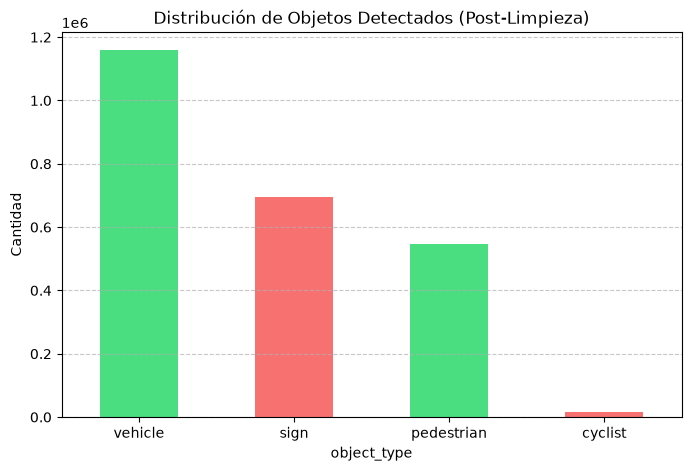

In [3]:
clases = df_clean['object_type'].value_counts()

plt.figure(figsize=(8, 5))
clases.plot(kind='bar', color=['#4ade80', '#f87171'])
plt.title("Distribución de Objetos Detectados (Post-Limpieza)")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Análisis Multivariado: Matriz de Correlación
Para entender cómo interactúan las variables cinemáticas y espaciales entre sí, calculamos la correlación de Pearson. Esto nos permite detectar si, por ejemplo, los vehículos más grandes (box_length) tienden a ir más lento, o la relación matemática entre los ejes.

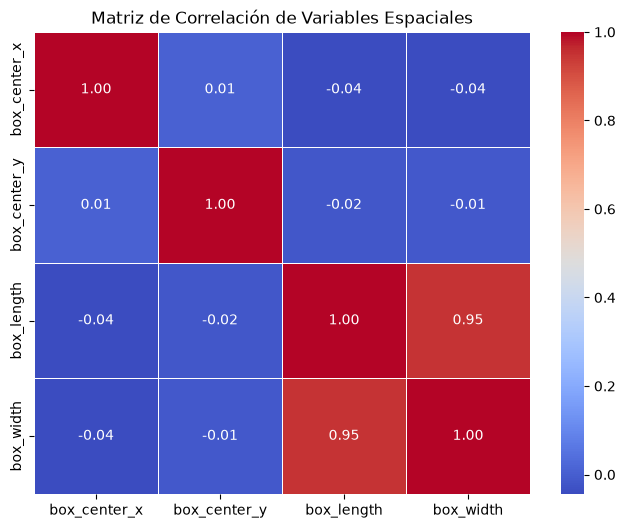

In [4]:
# Seleccionamos variables espaciales base
columnas_numericas = ['box_center_x', 'box_center_y', 'box_length', 'box_width']

# Excluimos variables estáticas sin varianza para evitar fallos matemáticos
for col in ['speed_x', 'speed_y', 'velocity_abs']:
    if col in df_clean.columns and df_clean[col].nunique() > 1:
        columnas_numericas.append(col)

correlacion = df_clean[columnas_numericas].corr()

# Visualización de la Matriz de Correlación usando SEABORN (Más robusto que Pandas Style)
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Variables Espaciales")
plt.show()

# 5. Auditoría Ética y Detección de Sesgos (Bias)

Como parte de la metodología CRISP-DM, es mandatorio auditar éticamente los datos antes de inyectarlos a un modelo de Machine Learning para prever sesgos algorítmicos. 

**Análisis de Clases Subrepresentadas:**
Como observamos en el gráfico de distribución de la sección 3, el dataset presenta un severo **desbalance de clases**. Los `vehicles` (vehículos) y `signs` (señales de tránsito) dominan casi por completo la muestra urbana, mientras que los `pedestrians` (peatones) o `cyclists` (ciclistas) son una **minoría estadística**.

**Impacto Ético:**
Si entrenáramos una red neuronal de toma de decisiones para un vehículo autónomo con este dataset exacto, el modelo aprendería a predecir y reaccionar excelentemente ante otros autos, pero **tendría una alta tasa de falsos negativos al detectar peatones**. En el mundo real, esto no es solo un error matemático, se traduce en un **riesgo vital** para los transeúntes (sesgo de representación).

**Estrategia de Mitigación recomendada para futuras Épicas:**
- **Oversampling (SMOTE):** Generar datos cinemáticos sintéticos para las clases minoritarias.
- **Undersampling:** Reducir aleatoriamente la cantidad de vehículos para equilibrar la muestra durante el entrenamiento.
- **Data Augmentation:** Recolectar o integrar más segmentos del *Waymo Open Dataset* enfocados exclusivamente en zonas urbanas densas (cruces peatonales) para equilibrar la realidad operativa del modelo.